<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/ARIMA_Liverpool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ARIMA Liverpool

#Librerías

In [1]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.7 MB/s eta 0:00:00


In [2]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 25.8 MB/s eta 0:00:00


In [3]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import math
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_absolute_error
from arch import arch_model
from sklearn.metrics import mean_absolute_percentage_error
from tabulate import tabulate

#Grupo México

In [47]:
#Obtener datos
df = yf.download('LIVEPOL1.MX', start='2024-01-01', end ='2026-06-26')

/tmp/ipykernel_825/2057216176.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('LIVEPOL1.MX', start='2024-01-01', end ='2026-06-26')
[*********************100%***********************]  1 of 1 completed


In [48]:
# Eliminar nivel del ticker
df.columns = df.columns.droplevel(1)

#Rendimientos

Vamos a usar los rendimientos logarítmicos para nuestros cálculos

In [49]:
#Obtener datos
precios = df['Close']

In [50]:
print(precios)

Date
2024-01-02    111.416786
2024-01-03    111.416786
2024-01-04    107.671677
2024-01-05    107.671677
2024-01-08    107.671677
                 ...    
2026-06-19    103.500000
2026-06-22    103.500000
2026-06-23    103.500000
2026-06-24    104.000000
2026-06-25    104.000000
Name: Close, Length: 621, dtype: float64


In [51]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-02         NaN
2024-01-03    0.000000
2024-01-04   -0.034191
2024-01-05    0.000000
2024-01-08    0.000000
                ...   
2026-06-19    0.000000
2026-06-22    0.000000
2026-06-23    0.000000
2026-06-24    0.004819
2026-06-25    0.000000
Name: Rendimientos_Log, Length: 621, dtype: float64


In [52]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-03    0.000000
2024-01-04   -0.034191
2024-01-05    0.000000
2024-01-08    0.000000
2024-01-09    0.000000
                ...   
2026-06-19    0.000000
2026-06-22    0.000000
2026-06-23    0.000000
2026-06-24    0.004819
2026-06-25    0.000000
Name: Rendimientos_Log, Length: 620, dtype: float64


#ARIMA

In [53]:
#Nuestro parámetros son p=0, d=0 y q=0
#Aplicamos ARIMA con la función que ya trae Python

modelo0 = ARIMA(df['Rendimientos_Log'].dropna(), order=(0,0,0))
resultado0 = modelo0.fit()

print(resultado0.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:       Rendimientos_Log   No. Observations:                  620
Model:                          ARIMA   Log Likelihood                1791.504
Date:                Tue, 30 Jun 2026   AIC                          -3579.008
Time:                        06:37:34   BIC                          -3570.149
Sample:                             0   HQIC                         -3575.565
                                - 620                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0001      0.001     -0.208      0.835      -0.001       0.001
sigma2         0.0002   2.22e-06     81.340      0.000       0.000       0.000
Ljung-Box (L1) (Q):                   0.20   Jarque-

In [60]:
#Hacemos la prueba para saber si necesitamos utilizar GARCH o no
#Si p<0.5 si se requiere, si p>0.5 no se requiere

from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(df['Rendimientos_Log'].dropna())

print("LM Statistic:", arch_test[0])
print("p-value:", arch_test[1])

LM Statistic: 3.1059396520409988
p-value: 0.9788197725561055


In [61]:
#Confirmaremos con Auto ARIMA que el modelo (0,0,0) es el mejor
Arima = auto_arima(df['Rendimientos_Log'])
print(Arima)

 ARIMA(0,0,0)(0,0,0)[0]          


In [63]:
#Hacemos prueba para saber si se requiere GARCH o no
residuos = resultado0.resid

for lag in [5,10,15,20]:
    lm, pvalue, _, _ = het_arch(residuos, nlags=lag)
    print(f"Lag={lag}: p-value={pvalue}")

Lag=5: p-value=0.9916004735226457
Lag=10: p-value=0.9778644488673586
Lag=15: p-value=0.9976614939117082
Lag=20: p-value=0.999791988906421


In [64]:
#Aunque no parece necesario GARCH lo vamos a utilizar GARCH(1,1)
garch = arch_model(
    residuos,
    mean='Zero',
    vol='GARCH',
    p=1,
    q=1
)

resultado_garch = garch.fit()
print(resultado_garch.summary())

Iteration:      1,   Func. Count:      4,   Neg. LLF: -1789.3785377778981
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1789.378537741338
            Iterations: 5
            Function evaluations: 4
            Gradient evaluations: 1
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.002
Vol Model:                      GARCH   Log-Likelihood:                1789.38
Distribution:                  Normal   AIC:                          -3572.76
Method:            Maximum Likelihood   BIC:                          -3559.47
                                        No. Observations:                  620
Date:                Tue, Jun 30 2026   Df Residuals:                      620
Time:                        06:41:27   Df Model:                            0
        

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.000181. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


#Predicción de Precio del día siguiente (29/06/26)


In [76]:
#Predicciones pero de los rendimientos log únicamente para el día siguiente

prediction = resultado0.forecast(steps=1)
print(prediction)

620   -0.000116
dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [79]:
#Vamos a convertir los rendimientos en precios
ultimo_precio = precios.iloc[-1]   # Último precio conocido

precio_pred = []
precio_actual = ultimo_precio

for r in prediction:
    precio_actual = precio_actual * np.exp(r)
    precio_pred.append(precio_actual)

In [80]:
#Prediccion precio del siguiente día de cotizacion (29/06/26)
precio_pred = pd.Series(precio_pred, index=prediction.index)

print(precio_pred)

620    103.987926
dtype: float64


##Estadísticos Bonda de Ajuste

In [86]:
#Obtener datos
hoy = yf.download('LIVEPOL1.MX', start='2026-06-29', end ='2026-06-30')

/tmp/ipykernel_825/3446559301.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hoy = yf.download('LIVEPOL1.MX', start='2026-06-29', end ='2026-06-30')
[*********************100%***********************]  1 of 1 completed


In [87]:
# Eliminar nivel del ticker
hoy.columns = hoy.columns.droplevel(1)

In [88]:
Precio_hoy = hoy['Close']
print(Precio_hoy)

Date
2026-06-29    104.0
Name: Close, dtype: float64


###Error Cuadrático Medio (RMSE)

In [89]:
rmse = np.sqrt(mean_squared_error(hoy['Close'], precio_pred))
print(f"RMSE = {rmse:.2f}")

RMSE = 0.01


In [90]:
rmse_porcentaje = (rmse / hoy['Close'].mean()) * 100
print(f"% RMSE ARIMA: {rmse_porcentaje:.4f} %")

% RMSE ARIMA: 0.0116 %


###Error Cuadrático Medio (MAE)

In [91]:
mae = mean_absolute_error(hoy['Close'], precio_pred)
print(f"MAE = {mae: .2f}")

MAE =  0.01


In [92]:
mae_porcentaje = (mae / hoy['Close'].mean()) * 100
print(f"% MAE ARIMA: {mae_porcentaje:.4f} %")

% MAE ARIMA: 0.0116 %


###Error Porcentual Absoluto Medio (MAPE)

In [93]:
mape = mean_absolute_percentage_error(hoy['Close'], precio_pred) * 100
print(f"MAPE = {mape: .4f} %")

MAPE =  0.0116 %


#Prueba con datos de entrenamiento

In [94]:
#Vamos a ver cuáles son los precios reales de los últimos 5 días
precios_reales = precios[-100:]
print(precios_reales)

Date
2026-01-29    100.283028
2026-01-30    102.839256
2026-02-03    102.839256
2026-02-04    102.858925
2026-02-05    102.858925
                 ...    
2026-06-19    103.500000
2026-06-22    103.500000
2026-06-23    103.500000
2026-06-24    104.000000
2026-06-25    104.000000
Name: Close, Length: 100, dtype: float64


In [95]:
train = precios[:-100]
test = precios[-100:]

In [96]:
ppredictions = resultado0.forecast(steps=100)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [97]:
ultimo_precio = train.iloc[-100]

pprecios_pred = []
precio_actual = ultimo_precio

for r in ppredictions:
    precio_actual = precio_actual * np.exp(r)
    pprecios_pred.append(precio_actual)

In [98]:
comparacion = pd.DataFrame({
    "Real": test,
    "Pronosticado": pprecios_pred
})

print(comparacion)

                  Real  Pronosticado
Date                                
2026-01-29  100.283028     99.115910
2026-01-30  102.839256     99.104403
2026-02-03  102.839256     99.092898
2026-02-04  102.858925     99.081393
2026-02-05  102.858925     99.069891
...                ...           ...
2026-06-19  103.500000     98.028695
2026-06-22  103.500000     98.017314
2026-06-23  103.500000     98.005935
2026-06-24  104.000000     97.994557
2026-06-25  104.000000     97.983180

[100 rows x 2 columns]


In [99]:
# Mostrar los resultados de las predicciones del 29/06/26 al 06/07/26
resultado = list(zip(test, pprecios_pred))

# Definimos los encabezados de la tabla
encabezados = ["Real", "Predicción"]

# Mostramos la tabla formateada
print(tabulate(resultado, headers=encabezados, tablefmt="grid"))

+---------+--------------+
|    Real |   Predicción |
+=========+==============+
| 100.283 |      99.1159 |
+---------+--------------+
| 102.839 |      99.1044 |
+---------+--------------+
| 102.839 |      99.0929 |
+---------+--------------+
| 102.859 |      99.0814 |
+---------+--------------+
| 102.859 |      99.0699 |
+---------+--------------+
| 102.859 |      99.0584 |
+---------+--------------+
| 102.053 |      99.0469 |
+---------+--------------+
| 100.293 |      99.0354 |
+---------+--------------+
| 104.216 |      99.0239 |
+---------+--------------+
| 104.216 |      99.0124 |
+---------+--------------+
| 104.216 |      99.0009 |
+---------+--------------+
| 102.053 |      98.9894 |
+---------+--------------+
| 102.053 |      98.9779 |
+---------+--------------+
| 102.053 |      98.9664 |
+---------+--------------+
| 102.053 |      98.9549 |
+---------+--------------+
| 102.053 |      98.9434 |
+---------+--------------+
| 102.053 |      98.932  |
+---------+--------------+
|

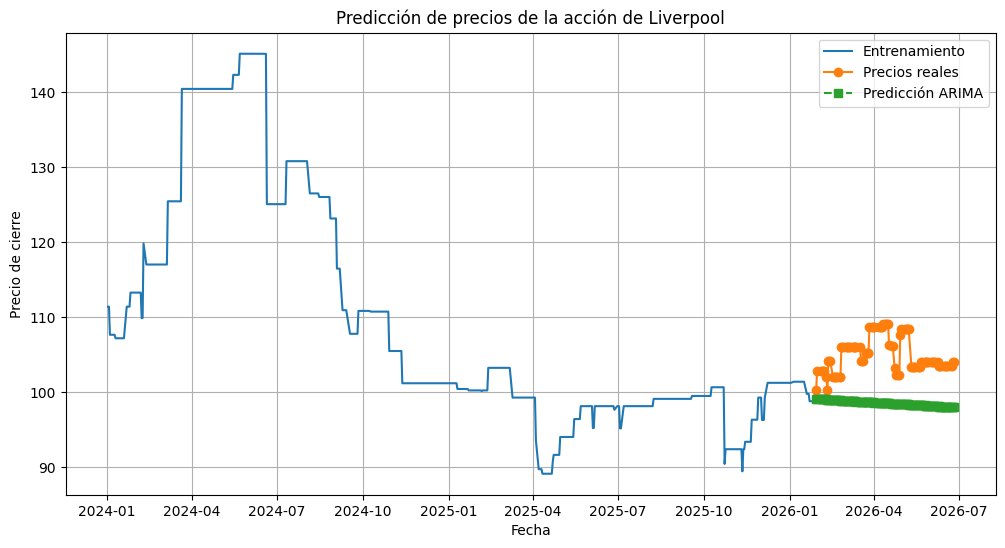

In [102]:
plt.figure(figsize=(12,6))

# Datos de entrenamiento
plt.plot(train.index, train,
         label='Entrenamiento')

# Datos reales
plt.plot(test.index, test,
         marker='o', label='Precios reales')

# Predicción
plt.plot(test.index, pprecios_pred,
         marker='s', linestyle='--',
         label='Predicción ARIMA')

plt.title('Predicción de precios de la acción de Liverpool')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre')
plt.legend()
plt.grid(True)

plt.show()

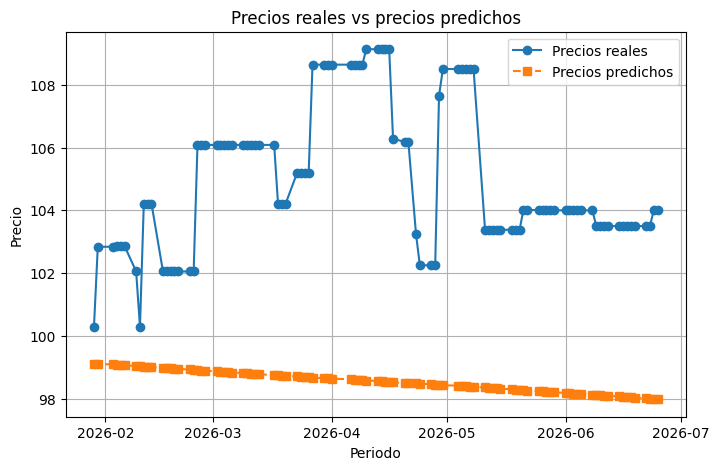

In [103]:
plt.figure(figsize=(8,5))

plt.plot(precios_reales.index, precios_reales,
         marker='o', label='Precios reales')

plt.plot(precios_reales.index, pprecios_pred,
         marker='s', linestyle='--', label='Precios predichos')

plt.title('Precios reales vs precios predichos')
plt.xlabel('Periodo')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)

plt.show()

##Estadísticos de Bondad de Ajuste

###Error Cuadrático Medio (RMSE)

In [104]:
rmse = np.sqrt(mean_squared_error(precios_reales, pprecios_pred))
print(f"RMSE = {rmse:.2f}")

RMSE = 6.76


In [105]:
rmse_porcentaje = (rmse / precios_reales.mean()) * 100
print(f"% RMSE Monte Carlo: {rmse_porcentaje:.4f} %")

% RMSE Monte Carlo: 6.4438 %


###Error Cuadrático Medio (MAE)

In [106]:
mae = mean_absolute_error(precios_reales, pprecios_pred)
print(f"MAE = {mae: .2f}")

MAE =  6.35


In [107]:
mae_porcentaje = (mae /precios_reales.mean()) * 100
print(f"% MAE Monte Carlo: {mae_porcentaje:.4f} %")

% MAE Monte Carlo: 6.0564 %


###Error Porcentual Absoluto Medio (MAPE)

In [108]:
mape = mean_absolute_percentage_error(precios_reales, pprecios_pred) * 100
print(f"MAPE = {mape: .4f} %")

MAPE =  6.0124 %


#Predicción para 100 días a partir del 29/06/26

In [109]:
predictions = resultado0.forecast(steps=100)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [110]:
ultimo_precio = precios.iloc[-1]

precios_pred = []
precio_actual = ultimo_precio

for r in predictions:
    precio_actual = precio_actual * np.exp(r)
    precios_pred.append(precio_actual)

In [111]:
fechas_pred = pd.date_range(
    start='2026-06-29',
    periods=100,
    freq='B' #Porque trabajamos con precios de la BMV
)

In [112]:
pronosticos = pd.DataFrame({
    "Fecha": fechas_pred,
    "Precio pronosticado": precios_pred
})

print(pronosticos)

        Fecha  Precio pronosticado
0  2026-06-29           103.987926
1  2026-06-30           103.975853
2  2026-07-01           103.963782
3  2026-07-02           103.951713
4  2026-07-03           103.939644
..        ...                  ...
95 2026-11-09           102.847269
96 2026-11-10           102.835329
97 2026-11-11           102.823390
98 2026-11-12           102.811452
99 2026-11-13           102.799516

[100 rows x 2 columns]


In [113]:
# Mostrar los resultados de las predicciones del 29/06/26 al 06/07/26
resultado = list(zip(fechas_pred, precios_pred))

# Definimos los encabezados de la tabla
encabezados = ["Fecha", "Predicción"]

# Mostramos la tabla formateada
print(tabulate(resultado, headers=encabezados, tablefmt="grid"))

+---------------------+--------------+
| Fecha               |   Predicción |
+=====================+==============+
| 2026-06-29 00:00:00 |      103.988 |
+---------------------+--------------+
| 2026-06-30 00:00:00 |      103.976 |
+---------------------+--------------+
| 2026-07-01 00:00:00 |      103.964 |
+---------------------+--------------+
| 2026-07-02 00:00:00 |      103.952 |
+---------------------+--------------+
| 2026-07-03 00:00:00 |      103.94  |
+---------------------+--------------+
| 2026-07-06 00:00:00 |      103.928 |
+---------------------+--------------+
| 2026-07-07 00:00:00 |      103.916 |
+---------------------+--------------+
| 2026-07-08 00:00:00 |      103.903 |
+---------------------+--------------+
| 2026-07-09 00:00:00 |      103.891 |
+---------------------+--------------+
| 2026-07-10 00:00:00 |      103.879 |
+---------------------+--------------+
| 2026-07-13 00:00:00 |      103.867 |
+---------------------+--------------+
| 2026-07-14 00:00:00 |  

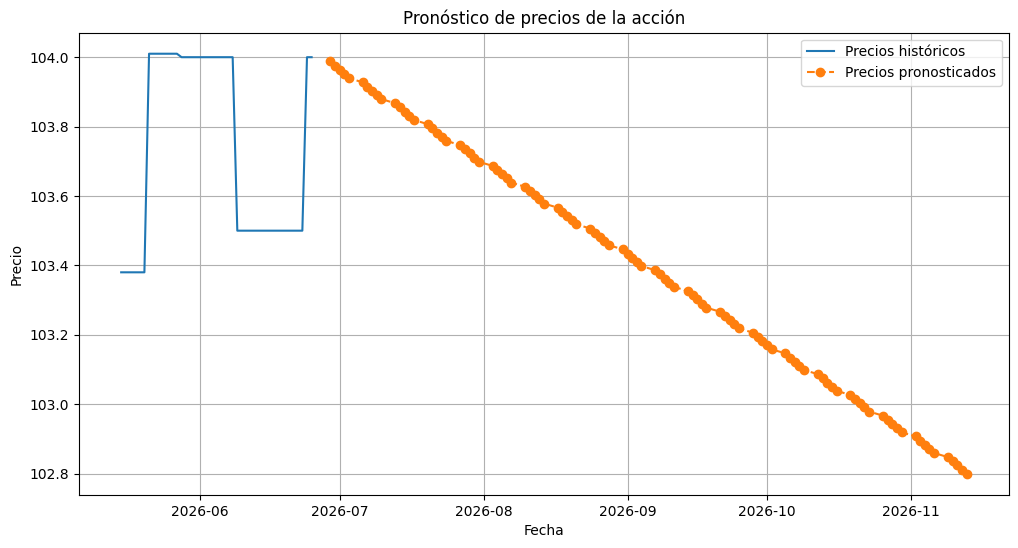

In [114]:
plt.figure(figsize=(12,6))

# Últimos precios históricos
plt.plot(precios.index[-30:], precios[-30:], label='Precios históricos')

# Predicciones
plt.plot(fechas_pred, precios_pred,
         marker='o',
         linestyle='--',
         label='Precios pronosticados')

plt.title('Pronóstico de precios de la acción')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)

plt.show()

###Estadísticos de Bondad de Ajuste